# 6 — Dual Training: Effect of Vote Filtering

Test the impact of filtering training data by minimum expert vote count (`min_votes`) on a `SequentialModel`.

**Motivation:** each sample in the dataset is labeled by multiple experts. Samples with few votes have noisier labels. This notebook tests whether training only on high-consensus samples improves model performance.

- **Run 1** (`min_votes=1`, all samples): no LR schedule, 15 epochs → best `val_loss=0.8115`
- **Run 2** (`min_votes=7`, high-consensus only): cosine schedule, 20 epochs → best `val_loss=0.4123`

The dramatic improvement in Run 2 confirms that label noise from low-vote samples is a major source of degradation. Note that the two runs are not directly comparable (different sample sets and label distributions), but the result guided the final training strategy.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch

import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from pytorch_lightning.loggers import TensorBoardLogger
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *


In [2]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

def plot_losses(log_dir="logs/dual"):
    versions = sorted(Path(log_dir).glob("version_*"), key=lambda p: int(p.name.split("_")[-1]))
    ea = EventAccumulator(str(versions[-1]))
    ea.Reload()

    def to_df(tag):
        events = ea.Scalars(tag)
        return pd.DataFrame({"epoch": [e.step for e in events], tag: [e.value for e in events]})

    train = to_df("train_loss")
    val   = to_df("val_loss")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train["epoch"], train["train_loss"], label="train loss")
    ax.plot(val["epoch"],   val["val_loss"],     label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Instantiation Data et Model


In [3]:
files_dir = PROCESSED_DIR / "cropped" / "files"
metadata = pd.read_csv(DATA_DIR / "train.csv")
model = SequentialModel(n_channels= 4, n_classes= 6, cnn_hidden_dims= [32,64,128,256],
                        lstm_hidden_size= 64, dropout= 0)


## Run 1 
### min_votes = 1

#### Callbacks and logger

In [4]:
callbacks_run1 = [
    ModelCheckpoint(
        dirpath="checkpoints/dual",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename="run1_{epoch:02d}-{val_loss:.3f}",
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        min_delta=1e-2,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

logger_run1 = TensorBoardLogger(save_dir="logs/", name="dual_run1", version=None)


In [5]:
lit_model_run1 = BrainLightning(model, lr=1e-3, mixup=True, scheduler=False)
dm_run1 = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, min_votes= 1)
trainer_run1 = pl.Trainer(
    max_epochs=15,
    accelerator="auto",
    devices="auto",
    callbacks=callbacks_run1,
    logger=logger_run1,
    precision="bf16-mixed",
    enable_progress_bar=True,
    log_every_n_steps=10,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [6]:
trainer_run1.fit(model= lit_model_run1, datamodule= dm_run1)

Filtered by 1: 17089/17089 kept
[setup] No cache found — computing 5-fold split (seed=273)

[setup] Fold 1/5 — 13672 train / 3417 val


  Fold 1 mean/std: 100%|██████████| 13672/13672 [00:06<00:00, 1959.18spec/s]


  → mean=1.1946, std=1.3467

[setup] Fold 2/5 — 13672 train / 3417 val


  Fold 2 mean/std: 100%|██████████| 13672/13672 [00:02<00:00, 5176.90spec/s]


  → mean=1.1729, std=1.3210

[setup] Fold 3/5 — 13672 train / 3417 val


...

Epoch 013 | val_loss:   0.8204

Epoch 013 - train_loss: 0.6045 - lr: 1.00e-03

Epoch 014 | val_loss:   0.8115

Epoch 014 - train_loss: 0.5983 - lr: 1.00e-03

`Trainer.fit` stopped: `max_epochs=15` reached.


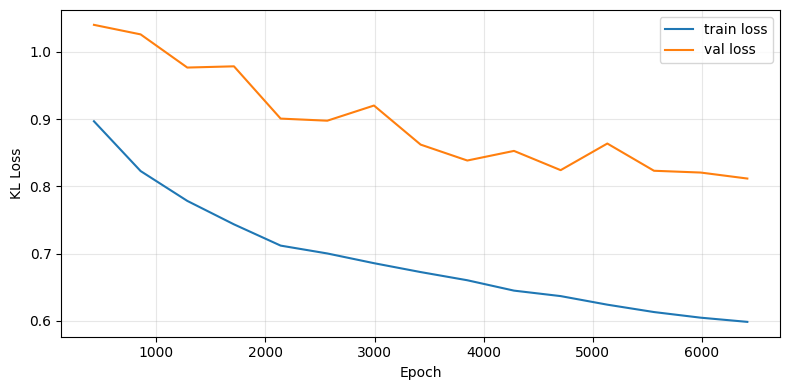

In [7]:
plot_losses(log_dir="logs/dual_run1")

In [8]:
checkpoint_cb = callbacks_run1[0]  # ModelCheckpoint
print(f"Best val_loss : {checkpoint_cb.best_model_score:.4f}")
print(f"Best checkpoint: {checkpoint_cb.best_model_path}")

Best val_loss : 0.8115
Best checkpoint: /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints/dual/run1_epoch=14-val_loss=0.812.ckpt


## Run 2
### min_votes= 7

In [ ]:
callbacks_run2 = [
    ModelCheckpoint(
        dirpath="checkpoints/dual",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename="run2_{epoch:02d}-{val_loss:.3f}",
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        mode="min",
        min_delta=1e-2,
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
]

logger_run2 = TensorBoardLogger(save_dir="logs/", name="dual_run2", version=None)


In [10]:
lit_model_run2 = BrainLightning(model, lr=1e-4, mixup=True, scheduler=True, t_max=20)
dm_run2 = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, min_votes= 7)
trainer_run2 = pl.Trainer(
    max_epochs=40,
    accelerator="auto",
    devices="auto",
    callbacks=callbacks_run2,
    logger=logger_run2,
    precision="bf16-mixed",
    enable_progress_bar=True,
    log_every_n_steps=10,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
trainer_run2.fit(model= lit_model_run2, datamodule= dm_run2)

Filtered by 7: 5939/17089 kept
[setup] No cache found — computing 5-fold split (seed=273)

[setup] Fold 1/5 — 4753 train / 1186 val


  Fold 1 mean/std: 100%|██████████| 4753/4753 [00:01<00:00, 2462.85spec/s]


  → mean=1.1549, std=1.3001

[setup] Fold 2/5 — 4751 train / 1188 val


  Fold 2 mean/std: 100%|██████████| 4751/4751 [00:01<00:00, 4510.40spec/s]


  → mean=1.1511, std=1.3177

[setup] Fold 3/5 — 4748 train / 1191 val


...

Epoch 008 - train_loss: 0.3468 - lr: 5.82e-05

Epoch 009 | val_loss:   0.4141

Epoch 009 - train_loss: 0.3466 - lr: 5.05e-05

Epoch 010 | val_loss:   0.4190

Epoch 010 - train_loss: 0.3467 - lr: 4.28e-05

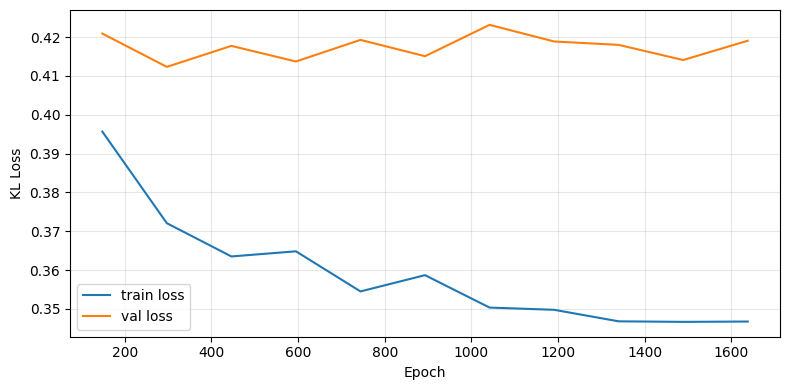

In [12]:
plot_losses(log_dir="logs/dual_run2")

In [13]:
checkpoint_cb = callbacks_run2[0]  # ModelCheckpoint
print(f"Best val_loss : {checkpoint_cb.best_model_score:.4f}")
print(f"Best checkpoint: {checkpoint_cb.best_model_path}")

Best val_loss : 0.4123
Best checkpoint: /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints/dual/run2_epoch=01-val_loss=0.412.ckpt


## Conclusion

Filtering by minimum vote count has a dramatic effect:

| Run | `min_votes` | Train samples | Best val_loss |
|-----|-------------|---------------|---------------|
| 1   | 1 (all data) | ~13 672       | **0.8115**    |
| 2   | 7 (high consensus only) | ~4 753 | **0.4123** |

⚠️ The two runs are **not directly comparable** (different sample sets and label distributions), so the absolute KL values cannot be compared directly.

However, the result confirms that **low-consensus samples introduce significant label noise** that harms training. Filtering for samples where experts strongly agree dramatically improves convergence.

**Decision:** use `min_votes` filtering in the final training pipeline. **Next:** hyperparameter search with the full Optuna framework (`7_optuna_v1`).